In [1]:
import numpy as np
import matplotlib.pyplot as plt

def PauliMatrices():
    p0 = np.eye(2, dtype=complex)
    p1 = np.array([[0, 1], [1, 0]], dtype=complex)
    p2 = np.array([[0, -1j], [1j, 0]], dtype=complex)
    p3 = np.array([[1, 0], [0, -1]], dtype=complex)
    return p0, p1, p2, p3

def cp(mu):
    return np.diag([mu] * 8)

def nmat(s):
    return np.zeros((s, s), dtype=complex)

def smat(a, s):
    return np.block([[a, nmat(s)], [nmat(s), a]])

def Hamiltonian(kx, ky):
    p0, p1, p2, p3 = PauliMatrices()

    s0 = lambda a: smat(a, 2)
    s1 = lambda a: np.block([[nmat(2), a], [a, nmat(2)]])
    s2 = lambda a: -1j * np.block([[nmat(2), a], [-a, nmat(2)]])
    s3 = lambda a: np.block([[a, nmat(2)], [nmat(2), -a]])

    s0c = lambda a: smat(a, 4)
    s1c = lambda a: np.block([[nmat(4), a], [a, nmat(4)]])
    s2c = lambda a: -1j * np.block([[nmat(4), a], [-a, nmat(4)]])
    s3c = lambda a: np.block([[a, nmat(4)], [nmat(4), -a]])

    def ArrayFlatten(matrix):
        return np.block(matrix)

    g0 = ArrayFlatten(s0(p0))
    g1p = ArrayFlatten((s0(p0) + s0(p3)) / 2)
    g1m = ArrayFlatten((s0(p0) - s0(p3)) / 2)
    g2p = ArrayFlatten((s1(p0) + 1j * s2(p0) + s1(p3) + 1j * s2(p3)) / 4)
    g2m = ArrayFlatten((s1(p0) + 1j * s2(p0) - s1(p3) - 1j * s2(p3)) / 4)
    g3 = ArrayFlatten((1j * s1(p2) - s2(p2)) / 2)
    g4p = ArrayFlatten((s0(p1) + s3(p1) + 1j * s0(p2) + 1j * s3(p2)) / 4)
    g4m = ArrayFlatten((s0(p1) - s3(p1) + 1j * s0(p2) - 1j * s3(p2)) / 4)
    g5p = ArrayFlatten((s3(p0) + s3(p3)) / 2)
    g5m = ArrayFlatten((s3(p0) - s3(p3)) / 2)
    g6 = ArrayFlatten((s1(p1) + 1j * s2(p1)) / 2)

    tpx = 1.13
    tdx = -0.41
    tpab = 0.40
    tdab = 0.51
    t0ab = 0.39
    t0abx = 0.29
    t0x = 0.14
    tpy = 0.13

    mup = -1.6
    mud = 0.74

    a = 3.477
    b = 6.249
    rad = np.array([-0.25 * a, 0.32 * b])
    rap = np.array([-0.25 * a, -0.07 * b])
    rbp = np.array([0.25 * a, 0.07 * b])
    rbd = np.array([0.25 * a, -0.32 * b])

    d1 = np.dot([kx, ky], (rad - rbd))
    d2 = np.dot([kx, ky], (rap - rbp))
    d3 = np.dot([kx, ky], (rad - rbp))
    d4 = np.dot([kx, ky], (rad - rap))

    l0aby = 0.011
    l0y = 0.051
    l0z = 0.012
    l0py = 0.050
    l0pz = 0.012
    lpxy = -0.040
    lpxz = -0.010
    ldxy = -0.031
    ldxz = -0.008

    hsoc = (
        (ldxz * s3c(g5p) + ldxy * s2c(g5p)) * np.sin(a * kx) +
        (lpxz * s3c(g5m) + lpxy * s2c(g5m)) * np.sin(a * kx) -
        1j * l0aby * s2c(g6) * (1 + np.exp(1j * a * kx)) * np.exp(1j * d3) -
        (1j * (l0z * s3c(g4p) + l0y * s2c(g4p)) * np.exp(1j * d4) -
         1j * (l0z * s3c(g4m) + l0y * s2c(g4m)) * np.exp(-1j * d4)) -
        (1j * (l0pz * s3c(g4p) + l0py * s2c(g4p)) * np.exp(-1j * b * ky) * np.exp(1j * d4) -
         1j * (l0pz * s3c(g4m) + l0py * s2c(g4m)) * np.exp(1j * b * ky) * np.exp(-1j * d4))
    )

    hsoc += hsoc.T.conj()

    h0b = (
        s0c((mup / 2 + tpx * np.cos(a * kx) + tpy * np.cos(b * ky)) * g1m +
            (mud / 2 + tdx * np.cos(a * kx)) * g1p +
            tdab * np.exp(-1j * b * ky) * (1.0 + np.exp(1j * a * kx)) * np.exp(1j * d1) * g2p +
            tpab * (1.0 + np.exp(1j * a * kx)) * np.exp(1j * d2) * g2m +
            t0ab * (1.0 - np.exp(1j * a * kx)) * np.exp(1j * d3) * g3 +
            t0abx * (np.exp(-1j * a * kx) - np.exp(2j * a * kx)) * np.exp(1j * d3) * g3 -
            2j * t0x * np.sin(a * kx) * np.exp(1j * d4) * g4p -
            2j * t0x * np.sin(a * kx) * np.exp(-1j * d4) * g4m) +
        s0c((mup / 2 + tpx * np.cos(a * kx) + tpy * np.cos(b * ky)) * g1m +
            (mud / 2 + tdx * np.cos(a * kx)) * g1p +
            tdab * np.exp(-1j * b * ky) * (1.0 + np.exp(1j * a * kx)) * np.exp(1j * d1) * g2p +
            tpab * (1.0 + np.exp(1j * a * kx)) * np.exp(1j * d2) * g2m +
            t0ab * (1.0 - np.exp(1j * a * kx)) * np.exp(1j * d3) * g3 +
            t0abx * (np.exp(-1j * a * kx) - np.exp(2j * a * kx)) * np.exp(1j * d3) * g3 -
            2j * t0x * np.sin(a * kx) * np.exp(1j * d4) * g4p -
            2j * t0x * np.sin(a * kx) * np.exp(-1j * d4) * g4m).T.conj()
    )



    h = hsoc + h0b 
    return h

a = 3.477
b = 6.249

# Set ky to 0 and kx from -pi to pi with 400 divisions
kx_values = np.linspace(-np.pi/a, np.pi/a, 400)
ky = 0


mu = 90
# Initialize a list to store eigenvalues
eigenvalues = []

# Diagonalize Hamiltonian for each kx and store the eigenvalues
for kx in kx_values:
    h = Hamiltonian(kx, ky/b)*1000 - cp(mu)
    eigvals = np.linalg.eigvalsh(h)  # Use eigvalsh for Hermitian matrices
    eigenvalues.append(eigvals)

# Convert eigenvalues list to a numpy array for easier manipulation
eigenvalues = np.array(eigenvalues)


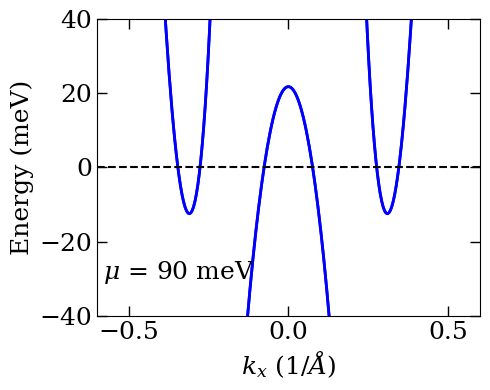

In [6]:

plt.rcParams["figure.figsize"] = [5, 4]
plt.rcParams["figure.autolayout"] = True
plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["mathtext.fontset"] = "dejavuserif"  # or "stix"

# Plot the band structure
# plt.figure(figsize=(8, 4))
for band in range(eigenvalues.shape[1]):
    plt.plot(kx_values, eigenvalues[:, band], color = 'b', lw = 2)
plt.tick_params(direction='in', length=7, width=1, colors='k', bottom=True,
                    top=True, left=True, right=True)
plt.xlabel(r'$k_x$ (1/$\AA$)', fontsize = 18)
plt.ylabel('Energy (meV)', fontsize = 18)
plt.ylim(-40,40)
plt.xlim(-0.6,0.6)
plt.text(-.58, -30, f"$\mu$ = {mu} meV", fontsize = 18)
plt.axhline(y = 0, ls = '--', color ='k')
plt.xticks([-0.5,0,0.5],fontsize=18)
plt.yticks([-40,-20,0,20,40],fontsize=18)
plt.savefig(f"band{mu}.png", dpi=300)
plt.savefig(f"band{mu}.pdf", dpi=300)
plt.show()
